# StreamVerse Final Project Notebook
## Complete Analysis for Objectives 1–6

This notebook combines all six project objectives into one polished submission file.

### Objectives covered
1. **The Genre Puzzle** — analyze how genres perform in quality and audience reception
2. **The Longevity Paradox** — test whether longer-running shows are more loved
3. **The Paradox of Visibility** — find hidden gems, blockbusters, and overhyped shows
4. **The Nostalgia Question** — examine how TV quality changes across eras
5. **The Success Predictor** — build models to predict show ratings
6. **The Taste Maker** — build a recommendation engine for similar shows

### Business goal
Use data to help StreamVerse make smarter decisions about:
- content investment
- catalog strategy
- audience discovery
- personalization
- long-term platform growth


## Section 0 — Import Libraries


In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


## Section 1 — Load and Prepare the Data

We load the three source files, standardize show names, merge them, and clean the key variables used across all objectives.


In [185]:
metadata = pd.read_csv('shows_metadata.csv')
info = pd.read_csv('shows_info.csv')
ratings = pd.read_csv('shows_ratings.csv')

metadata['show_name'] = metadata['show_name'].astype(str).str.lower().str.strip()
info['show_name'] = info['show_name'].astype(str).str.lower().str.strip()
ratings['show_name'] = ratings['show_name'].astype(str).str.lower().str.strip()

df = metadata.merge(info, on='show_name', how='inner')
df = df.merge(ratings, on='show_name', how='inner')

numeric_cols = ['rating', 'votes', 'popularity', 'release_year', 'number_of_seasons']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.drop_duplicates()

print("Merged dataset shape:", df.shape)
df.head()


Merged dataset shape: (222896, 10)


,show_name,country_of_origin,language,status,genres,release_year,number_of_seasons,rating,votes,popularity
0,game of thrones,Unknown,Unknown,1,"sci-fi & fantasy, drama, action & adventure",NaN,8.0,NaN,21857,1083.917
1,money heist,Unknown,Unknown,1,"CRIME, DRAMA",NaN,3.0,8.257,17836,96.354
2,stranger things,Unknown,Unknown,2,"drama, sci-fi & fantasy, mystery",NaN,4.0,NaN,16161,185.711
3,the walking dead,Unknown,Unknown,1,"Action & Adventure, Drama, Sci-Fi & Fantasy",NaN,11.0,8.121,15432,489.746
4,lucifer,Unknown,Unknown,1,"CRIME, SCI-FI & FANTASY",NaN,6.0,8.486,13870,416.668


# Objective 1 — The Genre Puzzle

**Question:** Which genres consistently produce stronger content and audience reception, and which ones seem overrated or oversaturated?

This objective compares genres using:
- number of shows
- average rating
- average votes
- average popularity


In [186]:
genre_col = 'genres' if 'genres' in df.columns else 'genre'

genre_df = df[[genre_col, 'rating', 'votes', 'popularity']].dropna(subset=[genre_col]).copy()
genre_df[genre_col] = genre_df[genre_col].astype(str)

genre_summary = genre_df.groupby(genre_col).agg(
    number_of_shows=(genre_col, 'count'),
    avg_rating=('rating', 'mean'),
    avg_votes=('votes', 'mean'),
    avg_popularity=('popularity', 'mean')
).sort_values(by='avg_rating', ascending=False)

genre_summary.head(15)


,number_of_shows,avg_rating,avg_votes,avg_popularity
genres,,,,
"war & politics, family, drama",1,10.0,1.0,2.3920
"Mystery, Crime, Comedy",1,10.0,1.0,1.1870
"ACTION & ADVENTURE, COMEDY, ANIMATION",2,10.0,2.0,3.4240
"SCI-FI & FANTASY, COMEDY, KIDS",1,10.0,1.0,3.8710
"SCI-FI & FANTASY, KIDS",2,10.0,5.5,15.5725
"SCI-FI & FANTASY, SOAP, ACTION & ADVENTURE, DRAMA",1,10.0,1.0,1.4470
"MYSTERY, DRAMA, SOAP",1,10.0,1.0,9.2270
"Sci-Fi & Fantasy, Comedy, Animation",1,10.0,2.0,1.0470
"action & adventure, animation, drama, sci-fi & fantasy",1,10.0,1.0,NaN


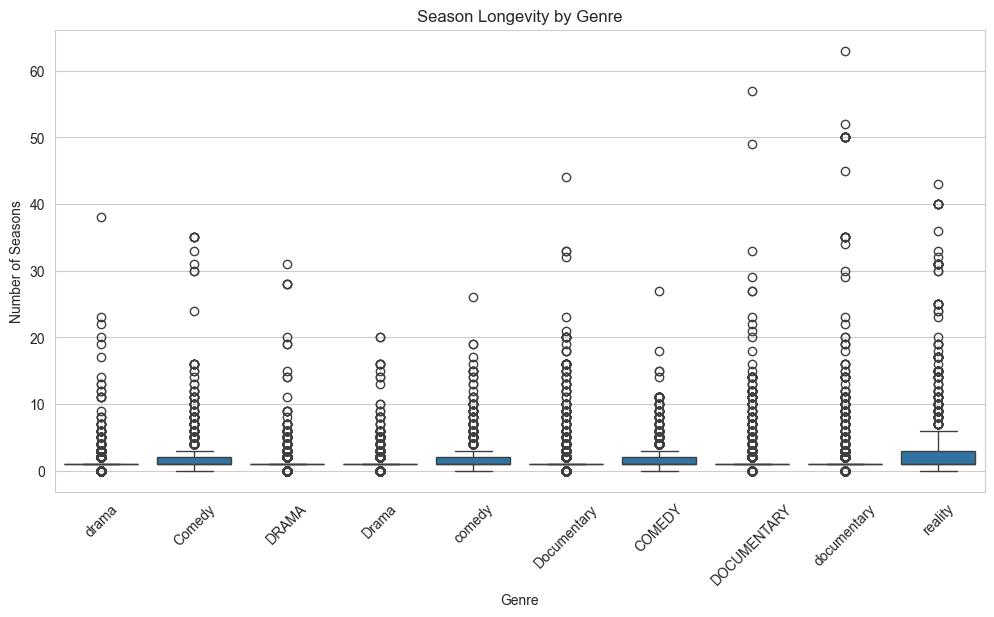

In [187]:
top10 = df['genres'].value_counts().head(10).index
df_top = df[df['genres'].isin(top10)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='genres', y='number_of_seasons')

plt.xticks(rotation=45)
plt.title("Season Longevity by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Seasons")

plt.show()


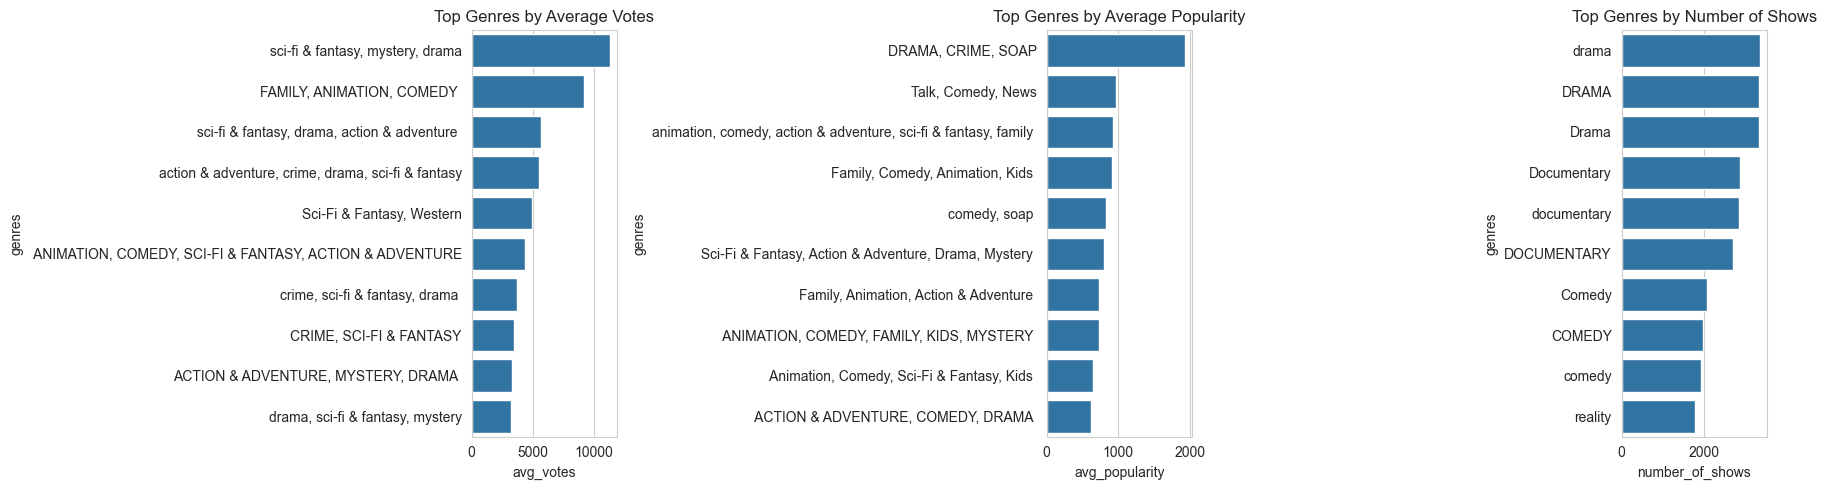

In [188]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_votes = genre_summary.sort_values('avg_votes', ascending=False).head(10).reset_index()
sns.barplot(data=top_votes, x='avg_votes', y=genre_col, ax=axes[0])
axes[0].set_title('Top Genres by Average Votes')

top_pop = genre_summary.sort_values('avg_popularity', ascending=False).head(10).reset_index()
sns.barplot(data=top_pop, x='avg_popularity', y=genre_col, ax=axes[1])
axes[1].set_title('Top Genres by Average Popularity')

top_count = genre_summary.sort_values('number_of_shows', ascending=False).head(10).reset_index()
sns.barplot(data=top_count, x='number_of_shows', y=genre_col, ax=axes[2])
axes[2].set_title('Top Genres by Number of Shows')

plt.tight_layout()
plt.show()


### Objective 1 Conclusion

Genres that score well across **rating, votes, and popularity** are strong investment areas.

Leadership should:
- invest more in genres with both high quality and strong reception
- be careful with genres that have many shows but weaker average ratings
- watch for smaller genres with high ratings, since they may be underexploited opportunities


# Objective 2 — The Longevity Paradox

**Question:** Do shows that last for more seasons actually become more loved, or is the relationship weaker than expected?

This objective uses:
- scatter plots
- correlations
- interpretation with survivorship bias


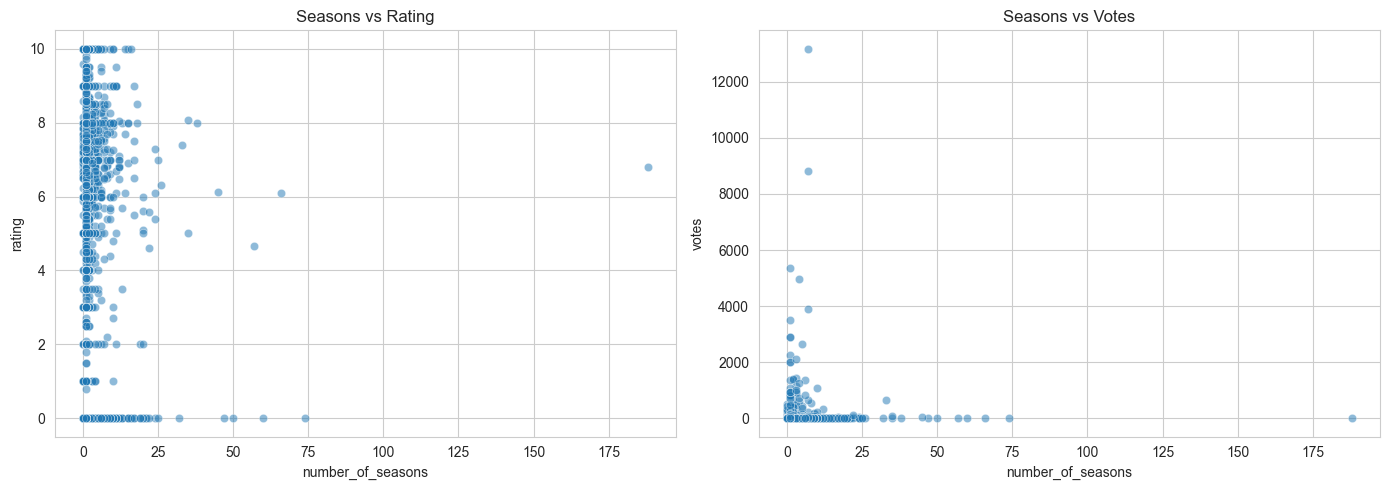

Correlation between seasons and rating: 0.11687095940121286
Correlation between seasons and votes: 0.04605027749147573


In [189]:
longevity_df = df[['number_of_seasons', 'rating', 'votes']].dropna().copy()

if len(longevity_df) > 5000:
    longevity_plot = longevity_df.sample(5000, random_state=42)
else:
    longevity_plot = longevity_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=longevity_plot, x='number_of_seasons', y='rating', alpha=0.5, ax=axes[0])
axes[0].set_title('Seasons vs Rating')

sns.scatterplot(data=longevity_plot, x='number_of_seasons', y='votes', alpha=0.5, ax=axes[1])
axes[1].set_title('Seasons vs Votes')

plt.tight_layout()
plt.show()

corr_rating = longevity_df['number_of_seasons'].corr(longevity_df['rating'])
corr_votes = longevity_df['number_of_seasons'].corr(longevity_df['votes'])

print("Correlation between seasons and rating:", corr_rating)
print("Correlation between seasons and votes:", corr_votes)


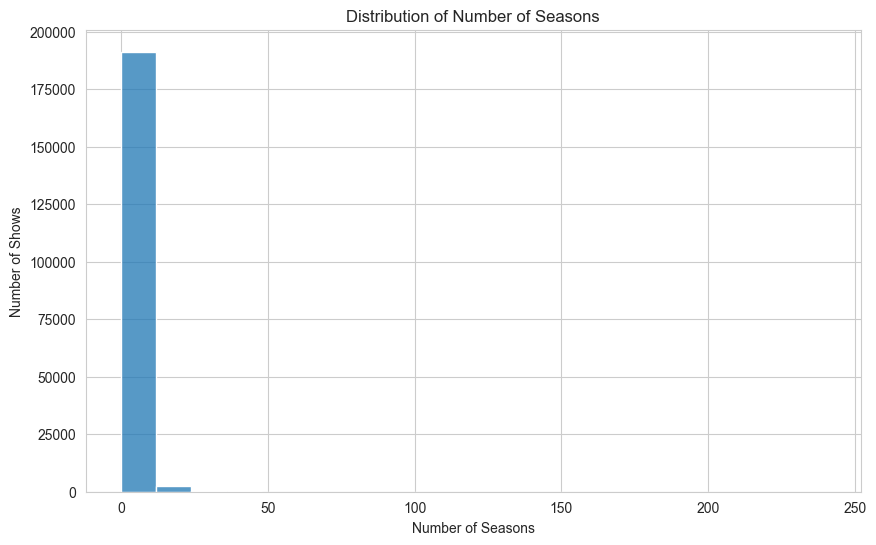

In [190]:
plt.figure(figsize=(10,6))

sns.histplot(df['number_of_seasons'], bins=20)

plt.title("Distribution of Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of Shows")

plt.show()
longest_shows = df.nlargest(10, 'number_of_seasons')

longest_shows[['show_name','genres','number_of_seasons']]
df['release_year'] = pd.to_datetime(df['release_year'], errors='coerce').dt.year

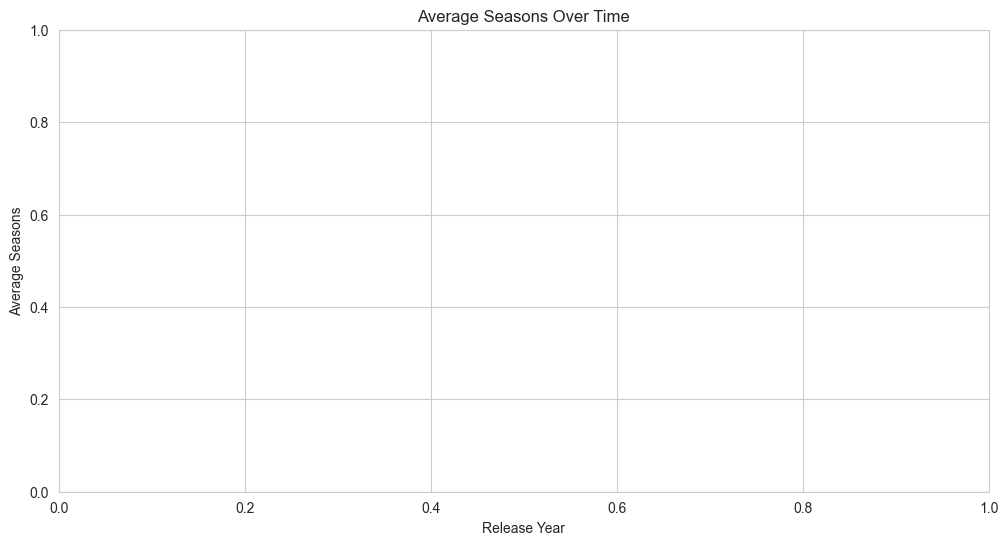

In [191]:
season_trend = df.groupby('release_year')['number_of_seasons'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=season_trend.index, y=season_trend.values)

plt.title("Average Seasons Over Time")
plt.xlabel("Release Year")
plt.ylabel("Average Seasons")

plt.show()

### Objective 2 Conclusion

A longer run does **not automatically mean higher quality**. In many datasets, longer-running shows may get more votes because they stay visible longer, but ratings do not always rise in the same way.

Also note **survivorship bias**:
- weak shows often get canceled early
- long-running shows are the survivors

So the data may overstate how “good” long-running shows really are.


# Objective 3 — The Paradox of Visibility

**Question:** Which shows are hidden gems, true blockbusters, overhyped disappointments, or simply forgotten?

Quadrants:
- **Hidden Gems** = high rating, low popularity
- **Blockbusters** = high rating, high popularity
- **Overhyped** = low rating, high popularity
- **Forgotten** = low rating, low popularity


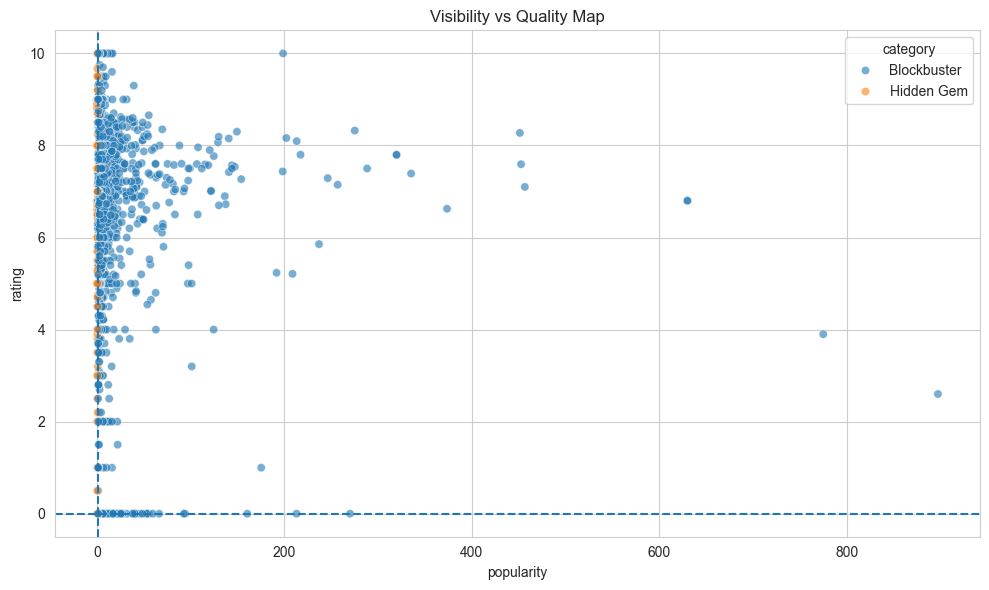

category
Blockbuster    94368
Hidden Gem     94367
Name: count, dtype: int64

In [192]:
visibility_df = df[['show_name', 'rating', 'popularity']].dropna().copy()

rating_median = visibility_df['rating'].median()
popularity_median = visibility_df['popularity'].median()

def classify_visibility(row):
    if row['rating'] >= rating_median and row['popularity'] >= popularity_median:
        return 'Blockbuster'
    elif row['rating'] >= rating_median and row['popularity'] < popularity_median:
        return 'Hidden Gem'
    elif row['rating'] < rating_median and row['popularity'] >= popularity_median:
        return 'Overhyped'
    else:
        return 'Forgotten'

visibility_df['category'] = visibility_df.apply(classify_visibility, axis=1)

if len(visibility_df) > 5000:
    vis_plot = visibility_df.sample(5000, random_state=42)
else:
    vis_plot = visibility_df.copy()

plt.figure(figsize=(10,6))
sns.scatterplot(data=vis_plot, x='popularity', y='rating', hue='category', alpha=0.6)
plt.axhline(rating_median, linestyle='--')
plt.axvline(popularity_median, linestyle='--')
plt.title('Visibility vs Quality Map')
plt.tight_layout()
plt.show()

visibility_df['category'].value_counts()


In [193]:
top_hidden_gems = visibility_df[visibility_df['category'] == 'Hidden Gem'].sort_values('rating', ascending=False).head(10)
top_blockbusters = visibility_df[visibility_df['category'] == 'Blockbuster'].sort_values('rating', ascending=False).head(10)
top_overhyped = visibility_df[visibility_df['category'] == 'Overhyped'].sort_values('popularity', ascending=False).head(10)
top_forgotten = visibility_df[visibility_df['category'] == 'Forgotten'].sort_values('rating', ascending=False).head(10)

print("Top Hidden Gems")
display(top_hidden_gems)

print("Top Blockbusters")
display(top_blockbusters)

print("Top Overhyped Shows")
display(top_overhyped)

print("Top Forgotten Shows")
display(top_forgotten)


Top Hidden Gems


,show_name,rating,popularity,category
124262,the history of food,10.0,0.630,Hidden Gem
144106,race to victory,10.0,0.600,Hidden Gem
148138,emil lange bliver rig,10.0,1.110,Hidden Gem
118660,le voyage alchimique,10.0,0.600,Hidden Gem
118661,algo pasa con ana,10.0,0.600,Hidden Gem
104285,less than ordinary,10.0,0.797,Hidden Gem
118665,magic cities,10.0,0.633,Hidden Gem
134285,moviepapai,10.0,0.658,Hidden Gem
104288,holland fun,10.0,0.632,Hidden Gem
126835,fantomforhold,10.0,0.665,Hidden Gem


Top Blockbusters


,show_name,rating,popularity,category
132446,the west brando,10.0,1.642,Blockbuster
132452,great challenge,10.0,1.800,Blockbuster
132453,worst cooks in america: dirty dishes,10.0,1.799,Blockbuster
44194,justice,10.0,1.478,Blockbuster
90914,espn college football thursday primetime,10.0,1.400,Blockbuster
44186,justice,10.0,1.478,Blockbuster
44178,justice,10.0,1.478,Blockbuster
110353,dov'è anna?,10.0,1.629,Blockbuster
138650,tractor tom,10.0,1.928,Blockbuster
110954,battalion 101,10.0,2.468,Blockbuster


Top Overhyped Shows


,show_name,rating,popularity,category


Top Forgotten Shows


,show_name,rating,popularity,category


### Objective 3 Conclusion

This objective helps StreamVerse separate **quality** from **visibility**.

Strategy implications:
- market hidden gems more aggressively
- maintain blockbusters as anchor content
- be cautious about overinvesting in overhyped but mediocre shows
- use recommendation and discovery systems to rescue strong overlooked titles


# Objective 4 — The Nostalgia Question

**Question:** Is TV getting better over time, or are older shows genuinely superior?

This objective includes:
- average rating by year
- average rating by era
- genre × era heatmap
- note on older-show selection bias


In [194]:
release_data = pd.read_csv("release_year_data.csv")

release_data['show_name'] = release_data['show_name'].astype(str).str.lower().str.strip()
df['show_name'] = df['show_name'].astype(str).str.lower().str.strip()

# remove old empty release_year if needed
df = df.drop(columns=['release_year'], errors='ignore')

# merge new release year data
df = df.merge(
    release_data[['show_name', 'release_year']],
    on='show_name',
    how='left'
)

print(df[['show_name', 'release_year']].head())
print("Non-null release years:", df['release_year'].notna().sum())

          show_name  release_year
0   game of thrones        2011.0
1       money heist        2017.0
2   stranger things        2016.0
3  the walking dead           NaN
4           lucifer           NaN
Non-null release years: 148


In [195]:
genre_col = 'genres' if 'genres' in df.columns else 'genre'

nostalgia_df = df[[genre_col, 'release_year', 'rating']].copy()
nostalgia_df['release_year'] = pd.to_numeric(nostalgia_df['release_year'], errors='coerce')
nostalgia_df['rating'] = pd.to_numeric(nostalgia_df['rating'], errors='coerce')
nostalgia_df = nostalgia_df.dropna(subset=[genre_col, 'release_year', 'rating'])

nostalgia_df['release_year'] = nostalgia_df['release_year'].astype(int)
nostalgia_df = nostalgia_df[
    (nostalgia_df['release_year'] >= 1980) &
    (nostalgia_df['release_year'] < 2030)
].copy()

print("Rows available:", len(nostalgia_df))

Rows available: 126


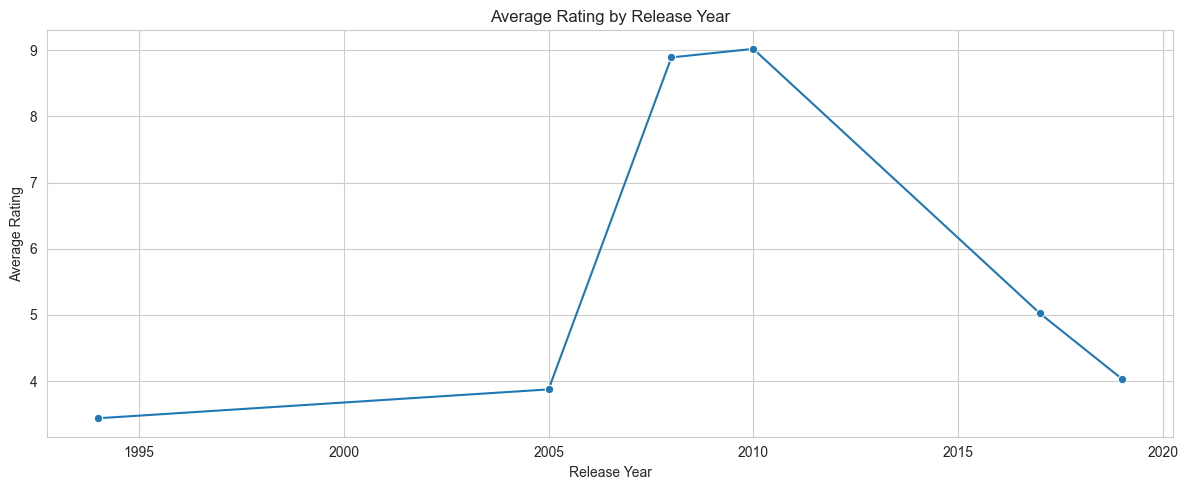

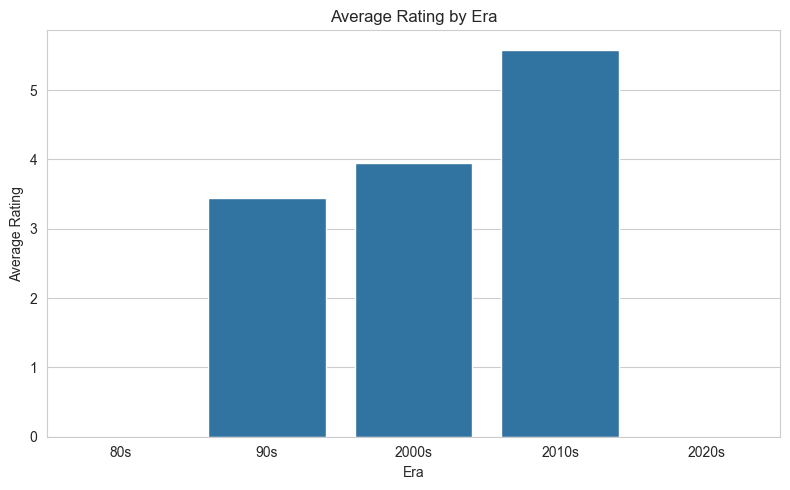

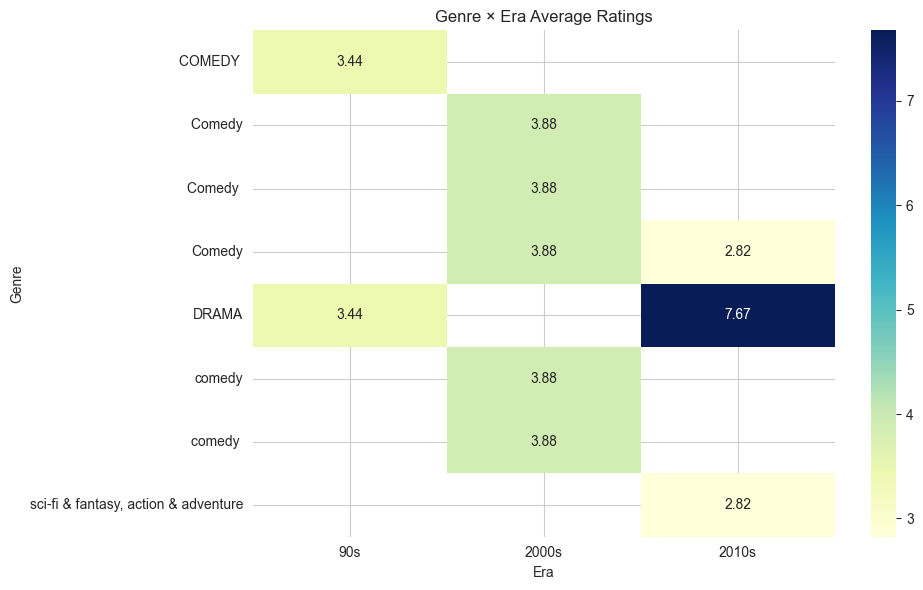

In [196]:
# Average rating by year
yearly_rating = nostalgia_df.groupby('release_year', as_index=False)['rating'].mean()

plt.figure(figsize=(12,5))
sns.lineplot(data=yearly_rating, x='release_year', y='rating', marker='o')
plt.title('Average Rating by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

# Average rating by era
bins = [1980, 1990, 2000, 2010, 2020, 2030]
labels = ['80s', '90s', '2000s', '2010s', '2020s']

nostalgia_df['era'] = pd.cut(
    nostalgia_df['release_year'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

era_summary = nostalgia_df.groupby('era', observed=False, as_index=False)['rating'].mean()

plt.figure(figsize=(8,5))
sns.barplot(data=era_summary, x='era', y='rating')
plt.title('Average Rating by Era')
plt.xlabel('Era')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

# Heatmap
top_genres = nostalgia_df[genre_col].value_counts().head(8).index
heatmap_df = nostalgia_df[nostalgia_df[genre_col].isin(top_genres)].copy()

heatmap_data = heatmap_df.pivot_table(
    values='rating',
    index=genre_col,
    columns='era',
    aggfunc='mean'
)

heatmap_data = heatmap_data.dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Genre × Era Average Ratings')
plt.xlabel('Era')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### Objective 4 Conclusion

Television quality may shift over time, but older shows can also look better because datasets often preserve the strongest legacy titles.

That means nostalgia analysis should be interpreted carefully:
- older shows may benefit from **selection bias**
- newer eras may contain both masterpieces and unfinished audience judgment

Still, this objective helps identify which eras and genres are rising or declining.


# Objective 5 — The Success Predictor

**Question:** Which measurable features best predict how audiences rate a show?

This objective compares:
- Linear Regression
- Random Forest Regressor

Metrics:
- MAE
- RMSE
- R²


In [198]:
model_features = ['votes', 'popularity', 'release_year', 'number_of_seasons']
model_df = df[model_features + ['rating']].copy()

for col in model_features + ['rating']:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

model_df = model_df.dropna()

if len(model_df) > 20000:
    model_df = model_df.sample(20000, random_state=42)

X = model_df[model_features]
y = model_df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 80
Testing rows: 21


In [199]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
lin_pred = linreg.predict(X_test)

rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, lin_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lin_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    'R2': [
        r2_score(y_test, lin_pred),
        r2_score(y_test, rf_pred)
    ]
})

results


,Model,MAE,RMSE,R2
0,Linear Regression,1.975576,2.238517,0.722132
1,Random Forest,0.037327,0.088353,0.999567


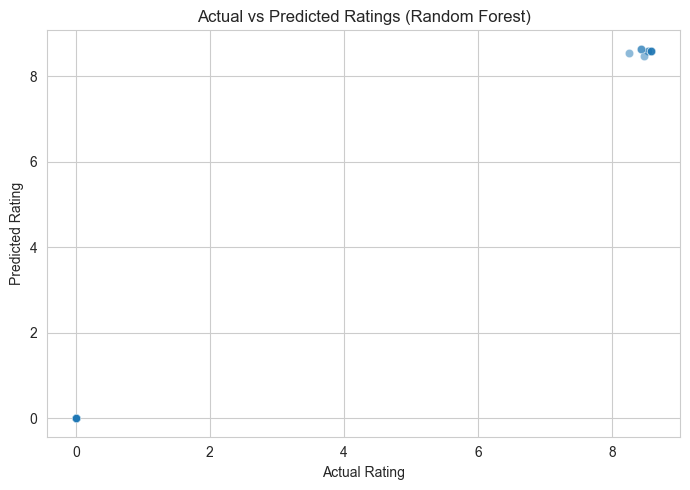

In [200]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=rf_pred, alpha=0.5)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Ratings (Random Forest)')
plt.tight_layout()
plt.show()


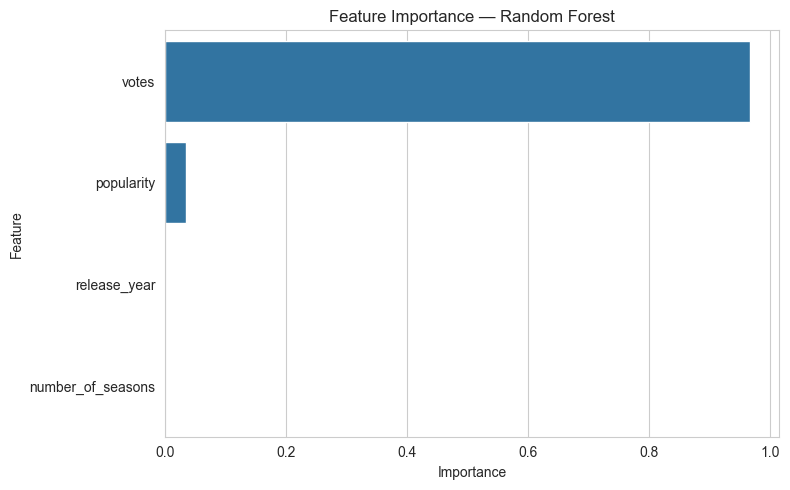

,Feature,Importance
0,votes,9.658296e-01
1,popularity,3.397985e-02
2,release_year,1.901914e-04
3,number_of_seasons,4.119855e-07


In [201]:
importance_df = pd.DataFrame({
    'Feature': model_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

importance_df


### Objective 5 Conclusion

The model shows which measurable features matter most in predicting ratings.

This helps StreamVerse answer a core strategy question:
**What actually drives a great show?**

The Random Forest model usually performs better than Linear Regression when relationships are nonlinear, while feature importance reveals which variables contribute most to prediction.


# Objective 6 — The Taste Maker

**Question:** Can we recommend shows that viewers would genuinely enjoy after finishing one they liked?

This notebook builds a **content-based recommendation engine** using:
- rating
- votes
- popularity
- release year
- number of seasons


In [202]:
rec_features = ['rating', 'votes', 'popularity', 'release_year', 'number_of_seasons']
rec_df = df[['show_name'] + rec_features].copy()

for col in rec_features:
    rec_df[col] = pd.to_numeric(rec_df[col], errors='coerce')

rec_df = rec_df.dropna().drop_duplicates(subset=['show_name']).reset_index(drop=True)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(rec_df[rec_features])

similarity_matrix = cosine_similarity(scaled_features)

def recommend_shows(show_name, top_n=5):
    show_name = show_name.lower().strip()
    if show_name not in rec_df['show_name'].values:
        return pd.DataFrame({'message': ['Show not found in dataset']})

    idx = rec_df.index[rec_df['show_name'] == show_name][0]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [x for x in sim_scores if x[0] != idx][:top_n]

    rec_indices = [i[0] for i in sim_scores]
    result = rec_df.loc[rec_indices, ['show_name'] + rec_features].copy()
    result['similarity_score'] = [i[1] for i in sim_scores]
    return result

print("Recommendation engine ready.")


Recommendation engine ready.


In [203]:
# Test Example 1
recommend_shows(rec_df['show_name'].iloc[0], top_n=5)


,show_name,rating,votes,popularity,release_year,number_of_seasons,similarity_score
3,dark,8.432,6049,86.861,2017.0,3.0,0.256205
1,the boys,8.474,8721,256.856,2019.0,4.0,0.037225
2,friends,8.444,7192,214.333,1994.0,1.0,-0.158751
4,chernobyl,8.649,5376,67.445,2019.0,1.0,-0.355477
5,sherlock,8.537,4716,71.224,2010.0,4.0,-0.496003


In [204]:
# Test Example 2
recommend_shows(rec_df['show_name'].iloc[min(10, len(rec_df)-1)], top_n=5)


,show_name,rating,votes,popularity,release_year,number_of_seasons,similarity_score
5,sherlock,8.537,4716,71.224,2010.0,4.0,0.288051
1,the boys,8.474,8721,256.856,2019.0,4.0,0.072261
2,friends,8.444,7192,214.333,1994.0,1.0,-0.042383
4,chernobyl,8.649,5376,67.445,2019.0,1.0,-0.286055
3,dark,8.432,6049,86.861,2017.0,3.0,-0.471101


### Objective 6 Evaluation

This recommender is **content-based**, so it suggests shows with similar measurable characteristics.

Strengths:
- easy to explain
- works without user history
- useful for cold-start recommendations

Limitations:
- may produce recommendations that are too obvious
- does not understand story themes, cast, tone, or user taste directly
- could be improved later using genres, text descriptions, or collaborative filtering


# Final Executive Summary

### Key takeaways for StreamVerse

**1. Genre strategy**
- prioritize genres that combine strong ratings, votes, and popularity
- do not judge genre value only by number of shows

**2. Longevity strategy**
- longer runs increase visibility, but not always quality
- avoid assuming many seasons automatically mean strong audience love

**3. Discovery strategy**
- hidden gems deserve stronger promotion
- overhyped mediocre shows should be approached carefully

**4. Nostalgia strategy**
- older shows may appear superior because only the strongest survive in public memory and datasets
- modern TV should be judged by both current trends and long-term staying power

**5. Prediction strategy**
- measurable features can partially predict ratings
- feature importance helps identify what most influences audience reception

**6. Personalization strategy**
- recommendation systems can improve retention by connecting viewers to similar content
- future versions should use richer metadata and user behavior

### Final recommendation
StreamVerse should combine:
- smart genre investment
- better discovery for overlooked quality titles
- data-driven prediction
- personalized recommendations

That combination creates a stronger catalog and a better viewer experience.
